In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 新段落

In [2]:
funnel = pd.read_csv('/content/08_strict_core_funnel_result.csv')
funnel

,stage_order,funnel_stage,session_count,overall_conversion_rate_pct,step_conversion_rate_pct,step_dropoff_rate_pct,lost_sessions
0,1,进入网站,354857,100.00,NaN,NaN,NaN
1,2,浏览商品,75264,21.21,21.21,78.79,279593.0
2,3,开始结账,10572,2.98,14.05,85.95,64692.0
3,4,完成购买,4592,1.29,43.44,56.56,5980.0


In [3]:
funnel = pd.read_csv('/content/08_strict_core_funnel_result.csv')

funnel

,stage_order,funnel_stage,session_count,overall_conversion_rate_pct,step_conversion_rate_pct,step_dropoff_rate_pct,lost_sessions
0,1,进入网站,354857,100.00,NaN,NaN,NaN
1,2,浏览商品,75264,21.21,21.21,78.79,279593.0
2,3,开始结账,10572,2.98,14.05,85.95,64692.0
3,4,完成购买,4592,1.29,43.44,56.56,5980.0


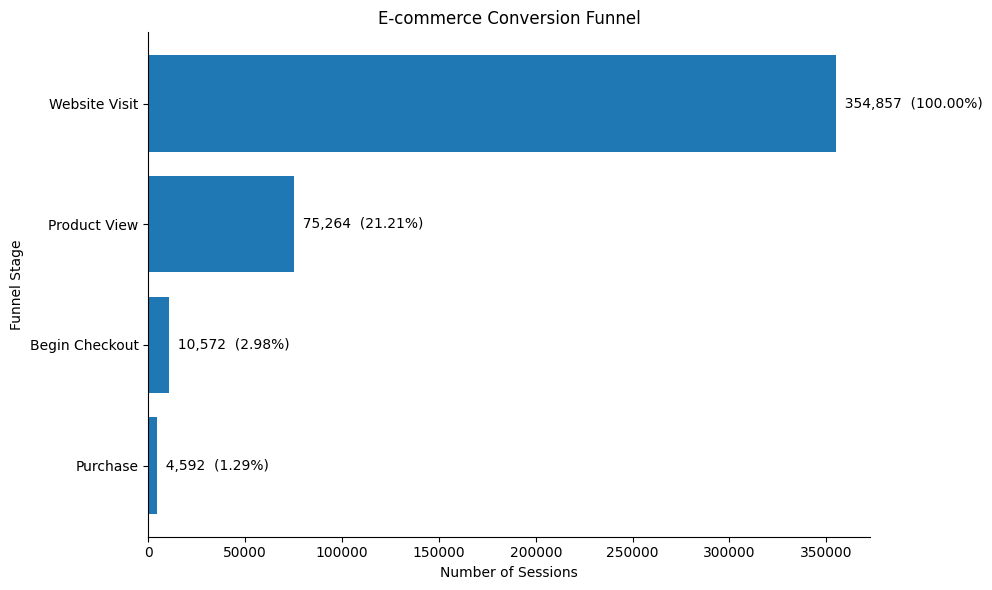

Step conversion rates:
Website Visit → Product View: 21.21%
Product View → Begin Checkout: 14.05%
Begin Checkout → Purchase: 43.44%


In [5]:
# 为作品集使用英文阶段名，避免中文字体问题
stage_names = [
    'Website Visit',
    'Product View',
    'Begin Checkout',
    'Purchase'
]

plot_df = funnel.copy()
plot_df['stage_name'] = stage_names

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_df['stage_name'],
    plot_df['session_count']
)

# 让漏斗从上往下
ax.invert_yaxis()

# 每个柱子后面显示：会话数 + 相对初始会话的转化率
for bar, count, rate in zip(
    bars,
    plot_df['session_count'],
    plot_df['overall_conversion_rate_pct']
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'  {count:,.0f}  ({rate:.2f}%)',
        va='center'
    )

ax.set_title('E-commerce Conversion Funnel')
ax.set_xlabel('Number of Sessions')
ax.set_ylabel('Funnel Stage')

# 去掉上、右边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/content/01_strict_core_funnel.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Step conversion rates:')

for i in range(1, len(plot_df)):
    previous_stage = plot_df.iloc[i - 1]['stage_name']
    current_stage = plot_df.iloc[i]['stage_name']
    rate = plot_df.iloc[i]['step_conversion_rate_pct']

    print(f'{previous_stage} → {current_stage}: {rate:.2f}%')

### 核心发现

严格会话级购买转化率为 1.29%。

相对流失最严重的环节主要发生在用户进入结账之前：

* 访问网站 → 浏览商品：21.21%
* 浏览商品 → 开始结账：14.05%
* 开始结账 → 完成购买：43.44%

这表明，最大的优化空间主要集中在购买漏斗的前段和中段，而不仅仅是在最终支付环节。



In [6]:
monthly = pd.read_csv('/content/14_monthly_funnel_summary_result.csv')

monthly

,month,total_sessions,view_sessions,checkout_sessions,purchase_sessions,session_to_view_rate_pct,view_to_checkout_rate_pct,checkout_to_purchase_rate_pct,overall_purchase_rate_pct
0,2020-11,106550,25289,4410,1532,23.73,17.44,34.74,1.44
1,2020-12,131793,27474,4157,2011,20.85,15.13,48.38,1.53
2,2021-01,116514,22501,2005,1049,19.31,8.91,52.32,0.90


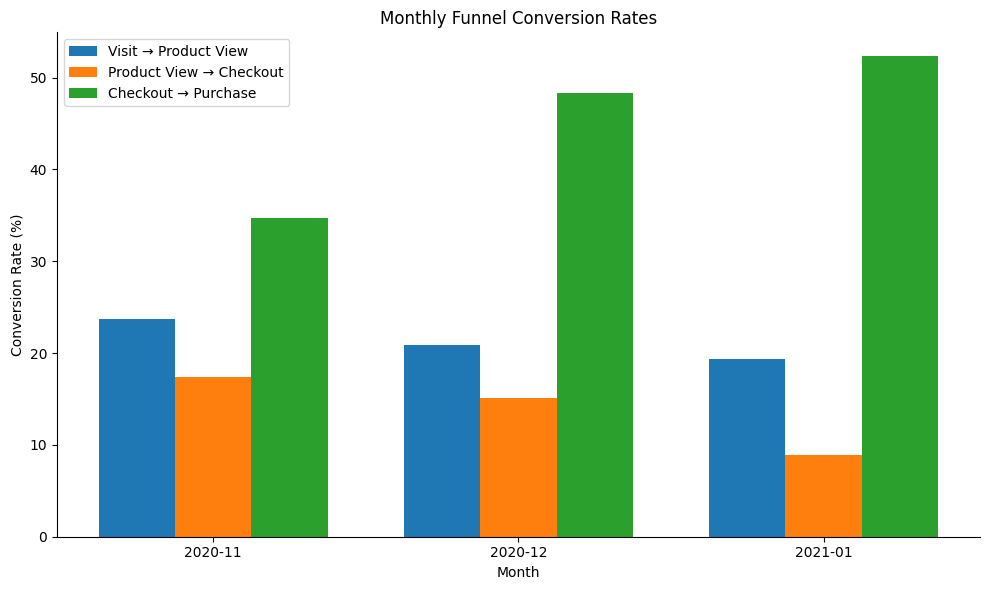

In [7]:
import numpy as np

x = np.arange(len(monthly))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width,
    monthly['session_to_view_rate_pct'],
    width,
    label='Visit → Product View'
)

ax.bar(
    x,
    monthly['view_to_checkout_rate_pct'],
    width,
    label='Product View → Checkout'
)

ax.bar(
    x + width,
    monthly['checkout_to_purchase_rate_pct'],
    width,
    label='Checkout → Purchase'
)

ax.set_xticks(x)
ax.set_xticklabels(monthly['month'])

ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Month')
ax.set_title('Monthly Funnel Conversion Rates')

ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/content/02_monthly_funnel_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

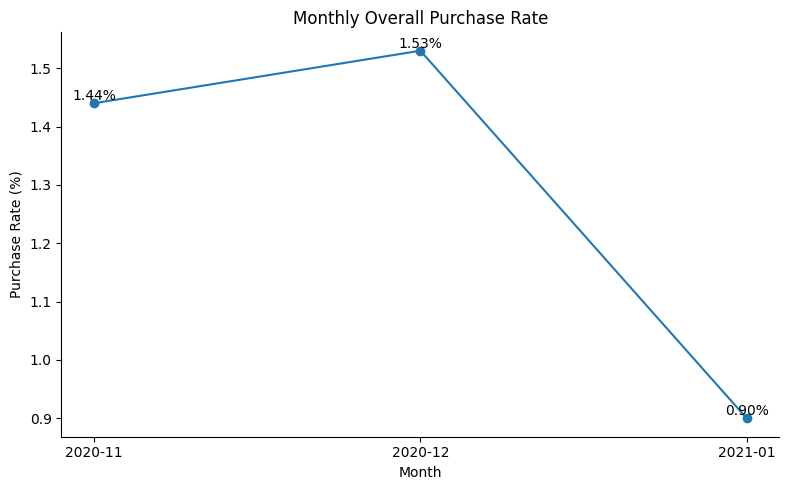

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    monthly['month'],
    monthly['overall_purchase_rate_pct'],
    marker='o'
)

for x_value, y_value in zip(
    monthly['month'],
    monthly['overall_purchase_rate_pct']
):
    ax.text(
        x_value,
        y_value,
        f'{y_value:.2f}%',
        ha='center',
        va='bottom'
    )

ax.set_title('Monthly Overall Purchase Rate')
ax.set_xlabel('Month')
ax.set_ylabel('Purchase Rate (%)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/content/02b_monthly_purchase_rate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

The overall purchase rate declined from 1.53% in December to 0.90% in January.

The decline was concentrated in the upper and middle funnel:
- Visit → Product View decreased from 20.85% to 19.31%.
- Product View → Checkout decreased sharply from 15.13% to 8.91%.
- Checkout → Purchase increased from 48.38% to 52.32%.

This suggests that the January decline was driven primarily by fewer visitors progressing toward checkout, rather than by deterioration in the final purchase completion stage.

The available data does not establish whether this was caused by traffic quality, product mix, promotions, inventory, or other business factors.

### 核心发现

整体购买率从 12 月的 1.53% 下降到 1 月的 0.90%。

这次下降主要集中在漏斗前半段和中段：

- 访问 → 浏览商品：从 20.85% 下降到 19.31%
- 浏览商品 → 开始结账：从 15.13% 大幅下降到 8.91%
- 开始结账 → 完成购买：反而从 48.38% 上升到 52.32%

这说明，1 月整体购买率下降，主要不是因为已经进入结账流程的用户没有完成购买，而是因为更少的用户从浏览商品继续进入结账阶段。

因此，后续更值得调查的方向包括流量质量、商品结构、促销活动、库存情况以及商品吸引力等。

但当前数据只能定位问题发生在哪个漏斗阶段，还不能证明具体是哪一个因素导致了转化率下降。

In [9]:
source = pd.read_csv(
    '/content/11_strict_core_funnel_by_source_result.csv'
)

source

,source_medium,total_sessions,view_sessions,checkout_sessions,purchase_sessions,session_to_view_rate_pct,view_to_checkout_rate_pct,checkout_to_purchase_rate_pct,overall_purchase_rate_pct
0,google / organic,111488,23271,3026,1181,20.87,13.00,39.03,1.06
1,(direct) / (none),82362,17310,2413,1038,21.02,13.94,43.02,1.26
2,<Other> / <Other>,51775,10489,1343,486,20.26,12.80,36.19,0.94
3,<Other> / referral,34110,7257,1018,449,21.28,14.03,44.11,1.32
4,shop.googlemerchandisestore.com / referral,28044,6383,1051,546,22.76,16.47,51.95,1.95
5,(data deleted) / (data deleted),21087,5274,1089,645,25.01,20.65,59.23,3.06
6,google / cpc,15534,3141,381,148,20.22,12.13,38.85,0.95
7,<Other> / organic,10078,2047,233,91,20.31,11.38,39.06,0.90


In [10]:
source[['source_medium', 'total_sessions', 'overall_purchase_rate_pct']]

,source_medium,total_sessions,overall_purchase_rate_pct
0,google / organic,111488,1.06
1,(direct) / (none),82362,1.26
2,<Other> / <Other>,51775,0.94
3,<Other> / referral,34110,1.32
4,shop.googlemerchandisestore.com / referral,28044,1.95
5,(data deleted) / (data deleted),21087,3.06
6,google / cpc,15534,0.95
7,<Other> / organic,10078,0.90


In [11]:
source_clean = source[
    ~source['source_medium'].str.contains(
        '<Other>|data deleted',
        case=False,
        na=False
    )
].copy()

source_clean = (
    source_clean
    .sort_values('total_sessions', ascending=False)
    .head(6)
)

source_clean[
    [
        'source_medium',
        'total_sessions',
        'overall_purchase_rate_pct'
    ]
]

,source_medium,total_sessions,overall_purchase_rate_pct
0,google / organic,111488,1.06
1,(direct) / (none),82362,1.26
4,shop.googlemerchandisestore.com / referral,28044,1.95
6,google / cpc,15534,0.95


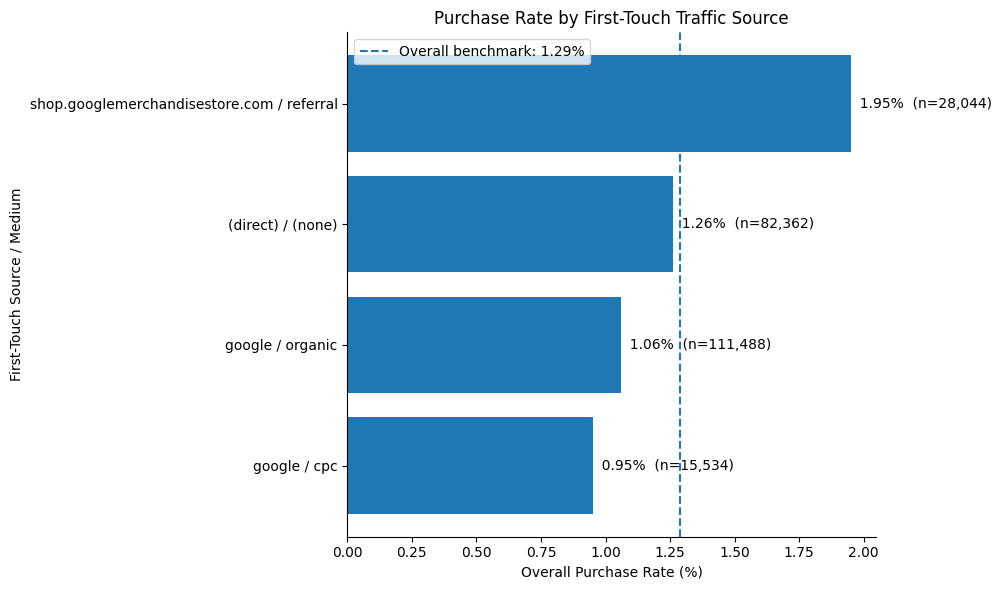

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_source = source_clean.sort_values(
    'overall_purchase_rate_pct',
    ascending=True
)

bars = ax.barh(
    plot_source['source_medium'],
    plot_source['overall_purchase_rate_pct']
)

for bar, rate, sessions in zip(
    bars,
    plot_source['overall_purchase_rate_pct'],
    plot_source['total_sessions']
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'  {rate:.2f}%  (n={sessions:,.0f})',
        va='center'
    )

# 整体购买率基准线
ax.axvline(
    1.29,
    linestyle='--',
    label='Overall benchmark: 1.29%'
)

ax.set_title(
    'Purchase Rate by First-Touch Traffic Source'
)

ax.set_xlabel(
    'Overall Purchase Rate (%)'
)

ax.set_ylabel(
    'First-Touch Source / Medium'
)

ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/content/03_source_purchase_rate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 核心发现

不同首次获客来源之间存在一定的购买转化差异。

Google 自然搜索和 Google CPC 都贡献了较大的流量规模，但整体购买率低于全站 1.29% 的基准水平。

这说明搜索渠道带来的用户值得进一步调查，尤其需要关注用户搜索意图与实际落地页面内容是否匹配。

但需要注意，traffic_source 表示的是用户首次获客来源，并不一定代表当前购买会话的真实来源。同时当前数据缺少广告成本，因此不能据此评价渠道 ROI，也不能直接建议调整广告预算。

In [13]:
product = pd.read_csv(
    '/content/24_product_quadrant_analysis_result.csv'
)

product.head()

,item_name,item_category,view_session_items,cart_after_view_session_items,checkout_after_view_session_items,strict_purchase_session_items,all_purchase_session_items,view_to_cart_rate_pct,view_to_checkout_rate_pct,strict_view_to_purchase_rate_pct,strict_purchase_coverage_pct,high_view_threshold,purchase_rate_benchmark,product_quadrant,estimated_gap_vs_benchmark,data_reliability_note
0,Google Women's Striped L/S,Home/Sale/,11484,3420,0,0,0,29.78,0.00,0.00,NaN,5727,0.83,高浏览 + 低转化,95.3,购买样本较少
1,Google F/C Long Sleeve Tee Charcoal,Home/Apparel/Men's / Unisex/,11417,2893,0,0,0,25.34,0.00,0.00,NaN,5727,0.83,高浏览 + 低转化,94.8,购买样本较少
2,Google Campus Bike Eco Tee Navy,Home/Apparel/Men's / Unisex/,13866,3517,33,22,40,25.36,0.24,0.16,55.00,5727,0.83,高浏览 + 低转化,92.9,可用于初步比较
3,Google F/C Long Sleeve Tee Ash,Men's / Unisex,9623,2774,0,0,0,28.83,0.00,0.00,NaN,5727,0.83,高浏览 + 低转化,79.9,购买样本较少
4,YouTube Icon Tee Grey,Home/Apparel/Men's / Unisex/,14083,2266,57,39,56,16.09,0.40,0.28,69.64,5727,0.83,高浏览 + 低转化,77.5,可用于初步比较


In [14]:
high_view_threshold = product['high_view_threshold'].iloc[0]
purchase_rate_benchmark = product['purchase_rate_benchmark'].iloc[0]

print('High-view threshold:', high_view_threshold)
print('Purchase-rate benchmark:', purchase_rate_benchmark)

High-view threshold: 5727
Purchase-rate benchmark: 0.83


/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 27983 (\N{CJK UNIFIED IDEOGRAPH-6D4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 35272 (\N{CJK UNIFIED IDEOGRAPH-89C8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:53: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4003/1392839268.py:55: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}

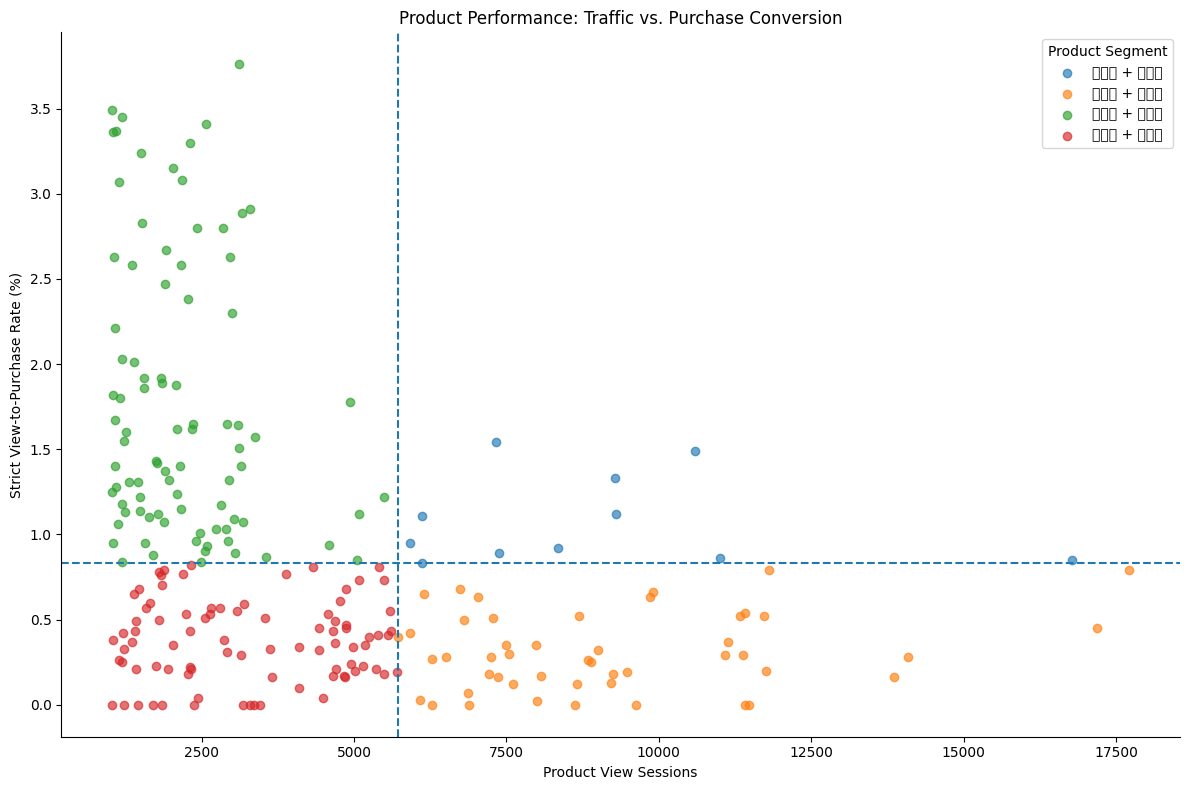

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

quadrants = [
    '高浏览 + 高转化',
    '高浏览 + 低转化',
    '低浏览 + 高转化',
    '低浏览 + 低转化'
]

for quadrant in quadrants:
    subset = product[
        product['product_quadrant'] == quadrant
    ]

    ax.scatter(
        subset['view_session_items'],
        subset['strict_view_to_purchase_rate_pct'],
        label=quadrant,
        alpha=0.65
    )

# 高浏览门槛
ax.axvline(
    high_view_threshold,
    linestyle='--'
)

# 整体商品转化率基准
ax.axhline(
    purchase_rate_benchmark,
    linestyle='--'
)

ax.set_title(
    'Product Performance: Traffic vs. Purchase Conversion'
)

ax.set_xlabel(
    'Product View Sessions'
)

ax.set_ylabel(
    'Strict View-to-Purchase Rate (%)'
)

ax.legend(
    title='Product Segment'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/content/04_product_quadrant.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [16]:
quadrant_map = {
    '高浏览 + 高转化': 'High Traffic / High Conversion',
    '高浏览 + 低转化': 'High Traffic / Low Conversion',
    '低浏览 + 高转化': 'Low Traffic / High Conversion',
    '低浏览 + 低转化': 'Low Traffic / Low Conversion'
}

product['quadrant_en'] = (
    product['product_quadrant']
    .map(quadrant_map)
)

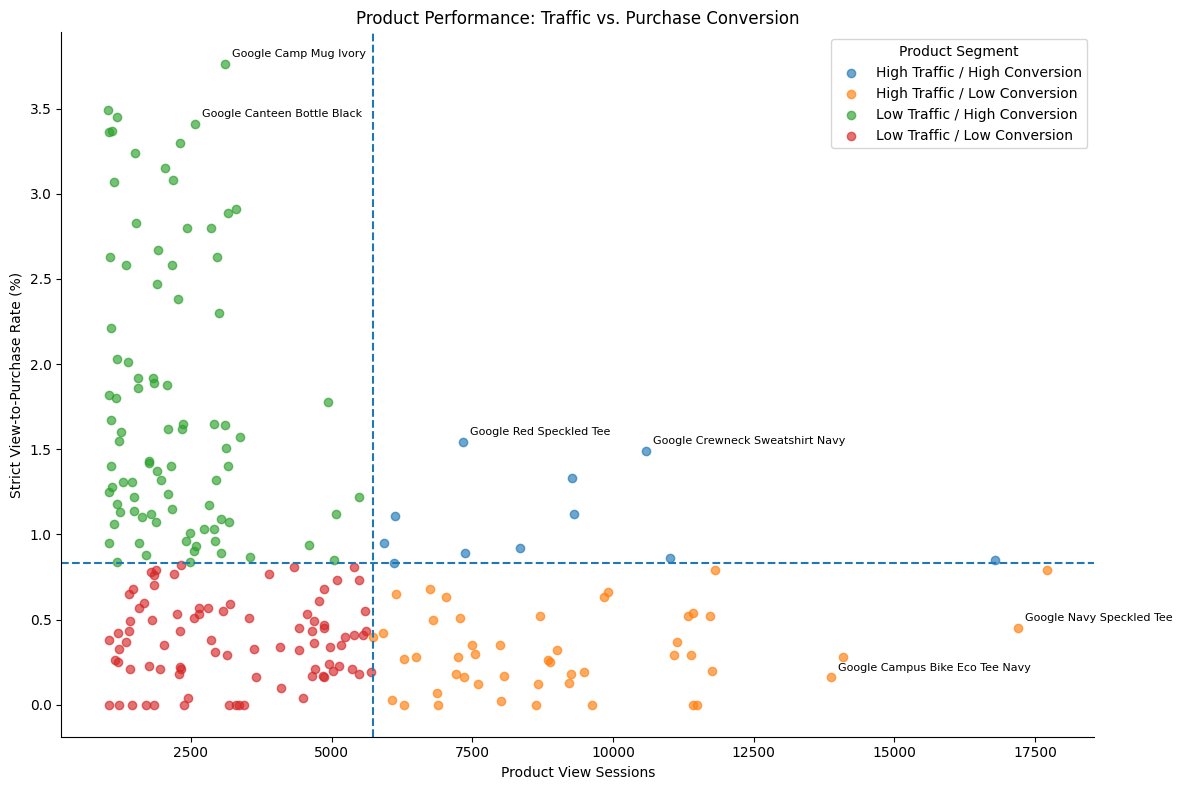

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

quadrants_en = [
    'High Traffic / High Conversion',
    'High Traffic / Low Conversion',
    'Low Traffic / High Conversion',
    'Low Traffic / Low Conversion'
]

for quadrant in quadrants_en:
    subset = product[
        product['quadrant_en'] == quadrant
    ]

    ax.scatter(
        subset['view_session_items'],
        subset['strict_view_to_purchase_rate_pct'],
        label=quadrant,
        alpha=0.65
    )

ax.axvline(
    high_view_threshold,
    linestyle='--'
)

ax.axhline(
    purchase_rate_benchmark,
    linestyle='--'
)

ax.set_title(
    'Product Performance: Traffic vs. Purchase Conversion'
)

ax.set_xlabel('Product View Sessions')
ax.set_ylabel('Strict View-to-Purchase Rate (%)')

ax.legend(title='Product Segment')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

products_to_label = [
    'Google Campus Bike Eco Tee Navy',
    'Google Navy Speckled Tee',
    'Google Red Speckled Tee',
    'Google Crewneck Sweatshirt Navy',
    'Google Camp Mug Ivory',
    'Google Canteen Bottle Black'
]

for _, row in product[
    product['item_name'].isin(products_to_label)
].iterrows():

    ax.annotate(
        row['item_name'],
        (
            row['view_session_items'],
            row['strict_view_to_purchase_rate_pct']
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    '/content/04_product_quadrant.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 核心发现

不同商品在浏览规模和购买转化效率上存在明显分化。

部分高浏览商品，例如 Google Campus Bike Eco Tee Navy，其严格浏览到购买率明显低于 0.83% 的整体商品基准，因此值得优先检查商品状态、库存、价格、SKU映射或页面信息等问题。

与此同时，一些浏览规模较低的商品，例如 Google Camp Mug Ivory，表现出了明显更高的购买转化率。

因此形成两个不同的业务机会：

1. 优先排查高浏览、低转化商品存在的问题。
2. 对低浏览、高转化商品增加曝光，并通过 A/B 实验验证是否能够提高整体购买表现。

需要注意，这些结果属于描述性分析，只能帮助定位异常和机会，不能证明造成商品转化差异的具体原因。
